<a href="https://colab.research.google.com/github/winniewytong/harvard_citation_checker/blob/main/harvard_citation_checker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openai pdf2image pillow PyMuPDF pdfminer.six

In [ ]:
!apt-get update -y
!apt-get install -y --fix-missing poppler-utils

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

In [ ]:
from openai import OpenAI
from google.colab import userdata
import os
import json
import time
from pathlib import Path
from typing import List, Dict, Any
import logging
import warnings
from datetime import datetime
from pdf2image import convert_from_path
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTTextContainer, LTChar
from PIL import Image
import base64
from io import BytesIO
import fitz
import re
from IPython.display import display, Markdown
cwd = os.getcwd()

# Configure logging to suppress the specific warning
logging.getLogger('pdfminer').setLevel(logging.ERROR)  # Raise the threshold to ERROR level
# Alternative approach using warnings filter
warnings.filterwarnings("ignore", category=UserWarning, module="pdfminer.pdfpage")

In [ ]:
SYSTEM_PROMPT= """
You are an automated academic referencing checker.
You are reviewing a Year 11 biology student's *Reference / bibliography * based on **Harvard referencing style** only. Year 11 students might not always cite peer-reviewed jounal articles but that is acceptable.
You are only provided the reference/ bibliography — there are no in-text citations to check.

## **Harvard Referencing Rules**

1. **General Formatting**:
- References must be alphabetised by the **first author’s surname**. Multiple works by the same author should be listed chronologically.
- If no author is provided, use the **organisation name**.
- If neither author nor organisation exists, order by **first significant word of the title** (ignoring “A”, “An”, or “The”).
- The reference list must be double-spaced with full blank lines between entries.
- Ensure proper spacing and punctuation, and italic format if applicable.

2. **Book Reference Format**:
- Author(s) Last name, First Initial(s). (Year). *Title*. Edition. Place of publication: Publisher.
- Example: Mitchell, J.A. and Thomson, M. (2017) *A guide to citation*. 3rd edn. London: London Publishings.

3. **Journal Article Format**:
- Author(s) Last name, First Initial(s). (Year). 'Title of article', *Title of Journal*, Volume(Issue), pp. page numbers.
- Example: Mitchell, J.A. (2013) ‘How citation changed the research world’, *The Mendeley*, 62(9), pp. 70–81.

4. **Website Reference Format**:
- Author(s) Last name, First Initial(s). (Year). *Title of webpage* [Online]. Available at: URL (Accessed: day month year).
- Example: Mitchell, J.A. (2017) *How and when to reference* [Online]. Available at: https://www.howandwhentoreference.com/ (Accessed: 27 May 2017).

5. **Edited Books, E-books, and Chapters**:
- Follow the standard Harvard rules for each type (edited books, e-books, book chapters).

## **Secondary Sources Criteria**

- Students must provide **4–8 valid and reliable secondary sources**.
- Valid sources include: books, journal articles, professional websites.
- Unreliable sources (blogs, Wikipedia, informal websites) are not acceptable.
- Some students might use journal articles but it is not expected.


## **Grading Rubric**

- **3 marks** = All references correct + 4–8 valid sources.
- **2 marks** = 1–2 minor errors, or slightly outside the 4–8 valid sources range.
- **1 mark** = Multiple errors, or major deviation from 4–8 valid sources.
- **0 marks** = Majority of references incorrect or clearly invalid sources.

## **Output Format**

Return a **valid JSON object** structured exactly as below:

```json
{
  "marks_awarded": integer,    // 3, 2, 1, or 0
  "number_of_references_provided": integer, // count total number of references provided
  "correct_alphabetically_order" : boolean, //true if references are correctly provided in the alphabetical order by author's last nameI, if no author is provided, use the organisation name. If neither author nor organisation exists, order by first significant word of the title, false if not in the specified order
  "suspicious_items": [
    {
      "reference": "string",   // the suspicious or incorrect reference, including items not in italic format or have spacing issues
      "issue": "string"        // concise factual explanation why it is wrong
    }
  ],
  "feedback": "string"          // brief overall feedback
}
```

## **Important Instructions**

- Only evaluate what is provided — do not invent references or errors.
- Keep explanations concise and factual.
- List only references that have issues inside `suspicious_items`.
- JSON must be valid, parsable, and match the required structure exactly.

## **Reference Separation Guidance**

- Each reference is typically separated by a full blank line (double-spaced).
- Treat each paragraph (text block separated by blank lines) as one reference.
- Do not split references across lines — if multiple lines are close together with no blank line between them, assume they are part of the same reference.
- Count the total number of distinct reference entries based on these paragraph breaks.
"""


In [ ]:
class CreateUploadFolder:
    def __init__(self, folder_name=None):
        self.cwd = os.getcwd()
        self.folder_name = folder_name or os.path.join(self.cwd, 'uploads')
        self.create_upload_folder()

    def create_upload_folder(self):
        Path(self.folder_name).mkdir(parents=True, exist_ok=True)
        print(f"Upload folder '{self.folder_name}' is ready.")

    def wait_for_uploads(self, expected_file_count=None):
        print(f"Please upload your PDF files into the '{self.folder_name}' folder.")

        while True:
            files = os.listdir(self.folder_name)
            pdf_files = [file for file in files if file.lower().endswith('.pdf')]

            if expected_file_count:
                if len(pdf_files) >= expected_file_count:
                    print(f"Detected {len(pdf_files)} PDF files. Proceeding...")
                    return pdf_files
                else:
                    print(f"Waiting for {expected_file_count} PDF files... (Currently {len(pdf_files)})")
            else:
                if pdf_files:
                    print(f"Detected {len(pdf_files)} PDF files. Proceeding...")
                    return pdf_files
                else:
                    print("Waiting for at least one PDF file...")

            time.sleep(5)  # Check every 5 seconds

    def main(self, expected_file_count=None):
        uploaded_files = self.wait_for_uploads(expected_file_count=expected_file_count)

        for pdf_file in uploaded_files:
            full_path = os.path.join(self.folder_name, pdf_file)
            print(f"Ready to process: {full_path}")

uploader = CreateUploadFolder()
uploader.main(expected_file_count=None)  # Or set to a specific number


Upload folder '/content/uploads' is ready.
Please upload your PDF files into the '/content/uploads' folder.
Detected 1 PDF files. Proceeding...
Ready to process: /content/uploads/citation_sample.pdf


In [ ]:

class CitationChecker:
    def __init__(self, pdf_path=None, batch_size=10):
        self.pdf_path = pdf_path
        self.SYSTEM_PROMPT = SYSTEM_PROMPT
        self.REFERENCE = None
        self.batch_size = batch_size
        self.client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

    def pdf_to_images(self, pdf_path):
    # Converts every page of the PDF to a 300dpi image
      return convert_from_path(pdf_path, dpi=300)

    def extract_italicised_text_pdfminer(self, pdf_path):
        italic_texts = []

        for page_layout in extract_pages(pdf_path):
            for element in page_layout:
                if isinstance(element, LTTextContainer):
                    for text_line in element:
                        line_text = ''
                        is_italic = False
                        for char in getattr(text_line, "_objs", []):  # This safely accesses characters
                            if isinstance(char, LTChar):
                                fontname = char.fontname.lower()
                                if 'italic' in fontname or 'oblique' in fontname:
                                    is_italic = True
                                line_text += char.get_text()
                        if is_italic and line_text.strip():
                            italic_texts.append(line_text.strip())

        return italic_texts


    def encode_image_to_base64(self, image):
        buffered = BytesIO()
        image.save(buffered, format="PNG")
        return base64.b64encode(buffered.getvalue()).decode()


    def process_single_pdf(self, pdf_path, filename):
        print(f"Processing file: {filename}")

        # Step 1: Extract italicised text using pdfminer
        italicised_segments = self.extract_italicised_text_pdfminer(pdf_path)

        # Step 2: Convert PDF to images for Vision input
        pdf_images = self.pdf_to_images(pdf_path)

        # Step 3: Use Vision API to get feedback
        feedback = self.citation_checker_v2(pdf_images)

        try:
            vision_json = json.loads(feedback)

            # Step 4: Correct false italicisation errors
            for item in vision_json.get("suspicious_items", []):
                if "italic" in item["issue"].lower():
                    if any(seg in item["reference"] for seg in italicised_segments):
                        item["issue"] = None  # Clear false positive

            # Clean suspicious_items list
            vision_json["suspicious_items"] = [
                item for item in vision_json["suspicious_items"] if item["issue"]
            ]

            return {
                "file": filename,
                "feedback": json.dumps(vision_json, indent =2)
            }
        except Exception as e:
            print("Error parsing Vision output:", e)
            return {
                "file": filename,
                "feedback": "Vision output failed to parse"
            }


    def citation_checker_v2(self, images):
        image_inputs = [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{self.encode_image_to_base64(img)}"}}
            for img in images
        ]
        try:

            response =  self.client.chat.completions.create(
                model="gpt-4.1",

                messages=[
                        {"role": "system", "content": self.SYSTEM_PROMPT},
                        {
                        "role": "user",
                        "content": [{"type": "text", "text": "Return output in json format"}] + image_inputs
                    }
                    ],
                    temperature=0.0,  # Controls creativity, between 0-1
                    top_p=1,
                    frequency_penalty=0,
                    presence_penalty=0,
                    response_format={"type": "json_object"},
                )

            return response.choices[0].message.content
        except Exception as e:
            print("Error:", e)
            return None

    def process_batch(self, pdf_files: List[tuple]):
        results = []
        for pdf_path, filename in pdf_files:
            result = self.process_single_pdf(pdf_path, filename)
            results.append(result)

        return results

    def process_pdfs_in_folder(self):
        all_results = []
        pdf_files = []

        # Gather all PDF files
        for filename in os.listdir(self.pdf_path):
            if filename.endswith(".pdf"):
                pdf_path = os.path.join(self.pdf_path, filename)
                pdf_files.append((pdf_path, filename))

        # Process files in batches
        for i in range(0, len(pdf_files), self.batch_size):
            batch = pdf_files[i:i + self.batch_size]
            print(f"Processing batch {i//self.batch_size + 1} ({len(batch)} files)")

            batch_results = self.process_batch(batch)
            all_results.extend(batch_results)

        return all_results

# Example usage:
def main():
    checker = CitationChecker(pdf_path=f"{cwd}/uploads", batch_size=10)
    results = checker.process_pdfs_in_folder()

    # Save as JSON
    curr_time = datetime.now().strftime("%Y%m%d%H%M%S")
    with open(f"saved_results_{curr_time}.json", "w") as outfile:
        json.dump(results, outfile, indent=2)

    print(f"Results saved to saved_results_{curr_time}.json")

    print("\nSample of results:")
    for result in results:
        print(f"File Name: {result['file']}")
        print(f"Feedback: {result['feedback']}")
        feedback_data = result["feedback"]
        if isinstance(feedback_data, str):
          feedback_data = json.loads(feedback_data)
        # Now display the formatted feedback
        display(Markdown(f"### 💬 Feedback:\n\n> {feedback_data['feedback']}"))
        pages = convert_from_path(f"{cwd}/uploads/{result['file']}", dpi=200)
        print("ORIGINAL WORK FROM STUDENT:")
        for img in pages:
          display(img)
        print("************************************************************************************************************************************************************************************************************")
        print()  # Empty line between results


Processing batch 1 (1 files)
Processing file: citation_sample.pdf
Results saved to saved_results_20250501051933.json

Sample of results:
File Name: citation_sample.pdf
Feedback: {
  "marks_awarded": 2,
  "number_of_references_provided": 11,
  "correct_alphabetically_order": false,
  "suspicious_items": [
    {
      "reference": "Brown, J (2020) The impact of technical leadership on organisational outcomes. London: Sage Publications.",
      "issue": "Missing period after initial. Title should be italicised."
    },
    {
      "reference": "Leadership Today (2021) Flexibility as the top leadership trait. Available at: https://www.leadershiptoday.com/flexibility (Accessed: 3 March 2024).",
      "issue": "Missing [Online] after title. Title should be italicised."
    },
    {
      "reference": "McKinsey and Company (no date) How remote work is shaping productivity. Available at: https://www.mckinsey.com/remote-work-productivity",
      "issue": "Missing [Online] after title, missing a

### 💬 Feedback:

> You provided a good number of valid sources, but there are consistent formatting errors: titles are not italicised, some web references lack [Online], and there are minor punctuation issues. Also, the references are not in perfect alphabetical order. Review Harvard style carefully for full marks.

ORIGINAL WORK FROM STUDENT:


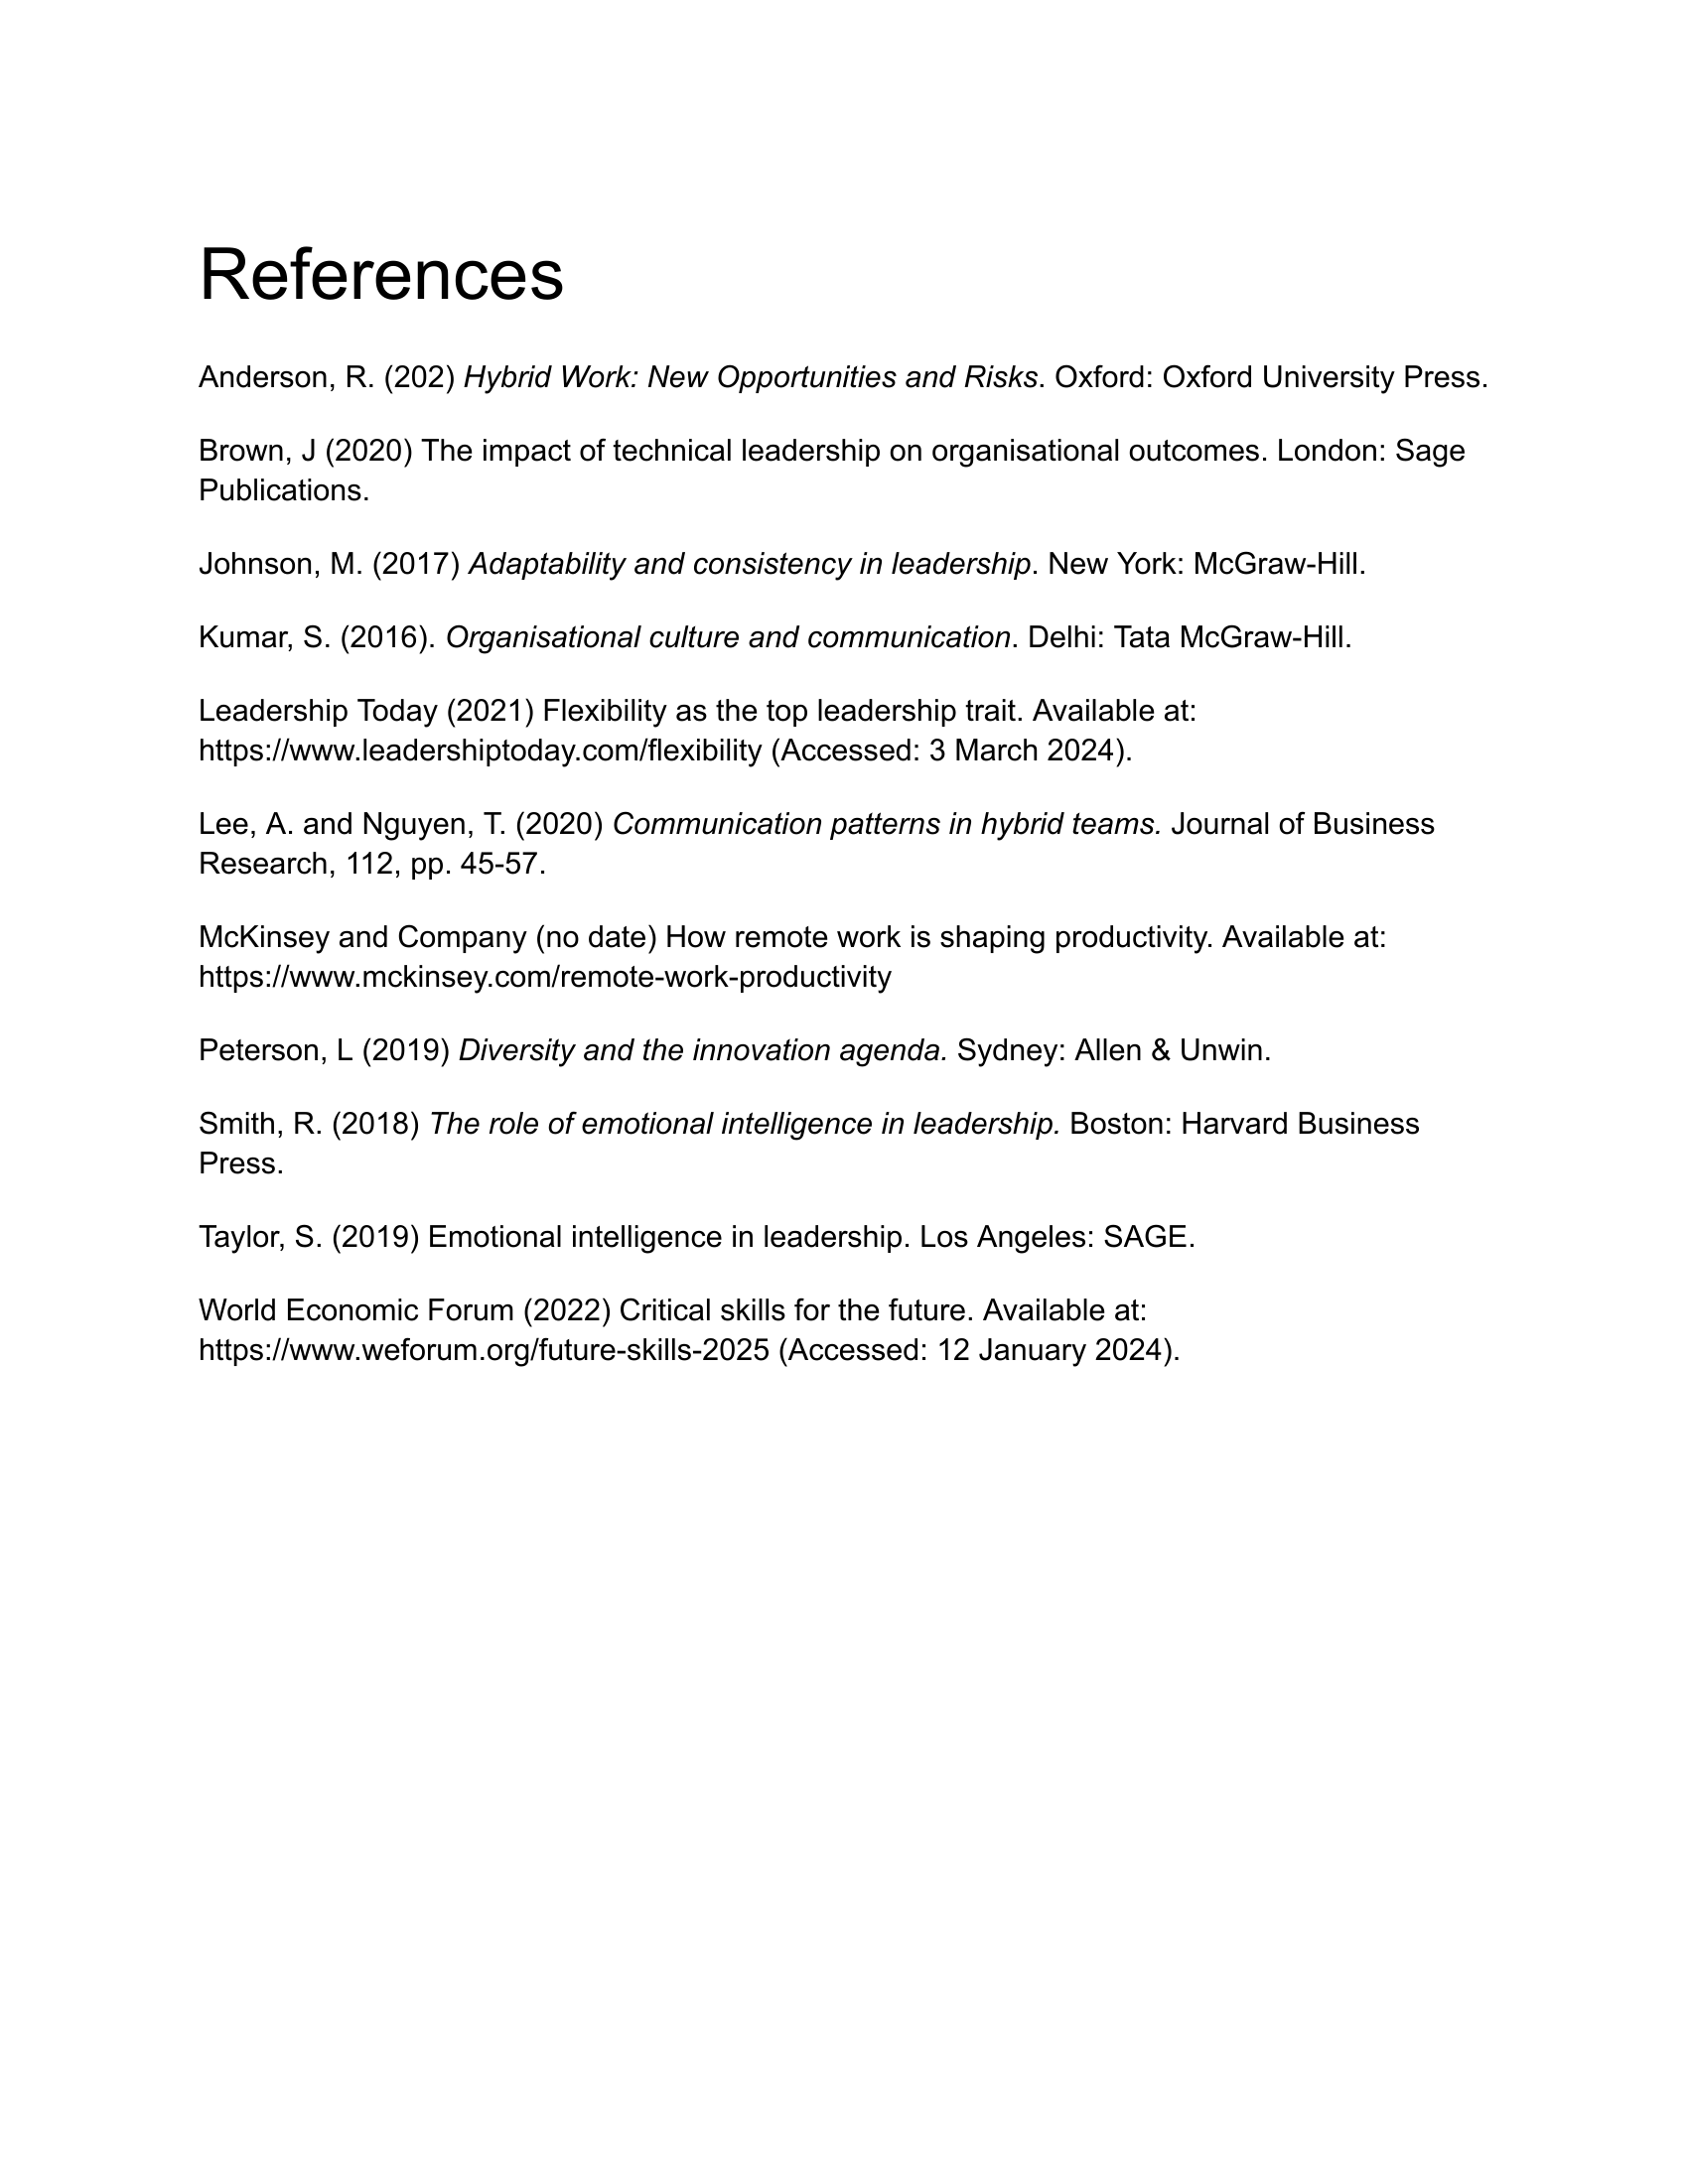

************************************************************************************************************************************************************************************************************



In [ ]:
main()

In [ ]:
#rm -r uploads